**CHIAMAKA EGBUKOLE**

**G40486569**

###Individual Homework 1
Reproducing the Lecture 1 COMPAS Workflow in Python

In [23]:
#IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import statsmodels.api as sm
import statsmodels.formula.api as smf


##1. Data Loading and Cleaning

In [24]:
#Load the raw COMPAS data
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
print(raw_data.shape)
raw_data.head()

(7214, 53)


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [25]:
#I kept the variables used in class slides
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
    "priors_count", "days_b_screening_arrest", "decile_score",
    "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

In [26]:
# Then I apply the same filtering rules from Lecture 1
df = df[
    (df["days_b_screening_arrest"] >= -30) &
    (df["days_b_screening_arrest"] <= 30) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["score_text"] != "N/A")
].copy()

print(df.shape)

(6172, 13)


In [27]:
#Type conversions and derived variables
df["c_jail_in"] = pd.to_datetime(df["c_jail_in"], errors="coerce")
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"], errors="coerce")

In [28]:
#I created the modeling variables:
df["crime_factor"] = df["c_charge_degree"]
df["age_factor"] = pd.Categorical(df["age_cat"], categories=["25 - 45", "Greater than 45", "Less than 25"])
df['race_factor'] = pd.Categorical(df['race'], categories=['Caucasian', 'African-American', 'Hispanic', 'Other', 'Asian', 'Native American'])
df["gender_factor"] = pd.Categorical(df["sex"], categories=["Male", "Female"])
df["score_factor"] = np.where(df["score_text"] != "Low", "HighScore", "LowScore")
df["score_factor"] = pd.Categorical(df["score_factor"], categories=["LowScore", "HighScore"])

In [29]:
#Basic EDA

print(df.info())
print(df.describe())

print(df["race"].value_counts())
print(df["score_text"].value_counts())
print(df["two_year_recid"].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   age                      6172 non-null   int64         
 1   c_charge_degree          6172 non-null   object        
 2   race                     6172 non-null   object        
 3   age_cat                  6172 non-null   object        
 4   score_text               6172 non-null   object        
 5   sex                      6172 non-null   object        
 6   priors_count             6172 non-null   int64         
 7   days_b_screening_arrest  6172 non-null   float64       
 8   decile_score             6172 non-null   int64         
 9   is_recid                 6172 non-null   int64         
 10  two_year_recid           6172 non-null   int64         
 11  c_jail_in                6172 non-null   datetime64[ns]
 12  c_jail_out               6172 non-null 

## Data Cleaning and Exploration

After applying the same filtering steps from Lecture 1, the dataset contains around 6,172 observations, which matches what we saw in class. This suggests that the preprocessing was done correctly.

From the summary statistics and plots, most defendants are classified as "Low" risk, with fewer in the "Medium" and "High" categories. The distribution of prior arrests is highly skewed to the right, meaning most individuals have few prior arrests, but a small number have many.

The race distribution also shows that African-American and Caucasian defendants make up the majority of the dataset, which is important to keep in mind when interpreting fairness results later.

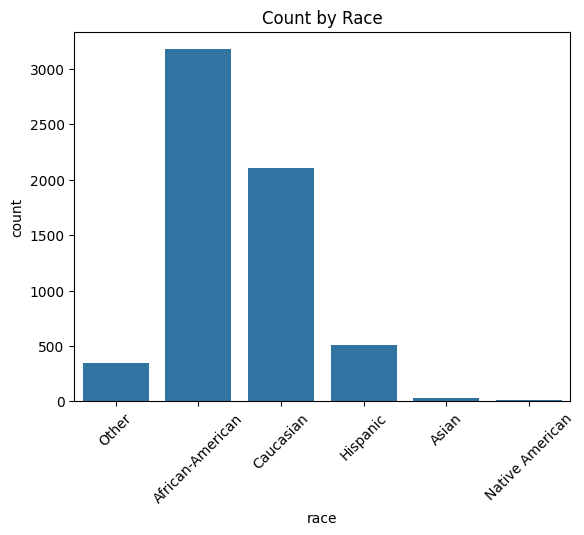

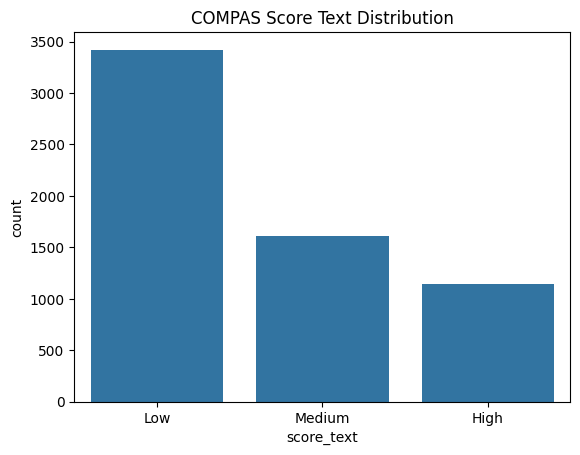

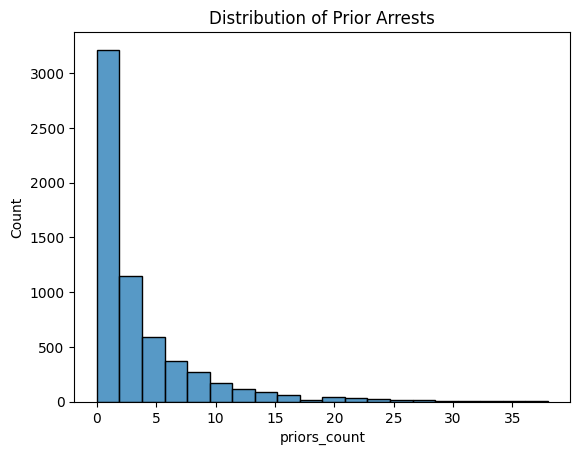

In [30]:
#Basic EDA visualizations

sns.countplot(data=df, x="race")
plt.title("Count by Race")
plt.xticks(rotation=45)
plt.show()

sns.countplot(data=df, x="score_text")
plt.title("COMPAS Score Text Distribution")
plt.show()

sns.histplot(df["priors_count"], bins=20)
plt.title("Distribution of Prior Arrests")
plt.show()

In [31]:
#Logistic Regression
df["high_score"] = np.where(df["score_factor"] == "HighScore", 1, 0)

model = smf.logit(
    formula="high_score ~ C(gender_factor) + C(age_factor) + C(race_factor) + priors_count + C(crime_factor) + two_year_recid",
    data=df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             high_score   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        19:12:32   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -1.5255      0.079    

In [32]:
#predicted probabilities and predicted classes, with binary predictions using a 0.5 threshold
df["pred_prob"] = model.predict(df)
df["pred_class"] = np.where(df["pred_prob"] >= 0.5, 1, 0)

My logistic regression shows that prior arrests and age are strong predictors of risk scores. Race variables are also significant, suggesting differences across groups.From the results, variables like prior arrests and age appear to be strong predictors of risk score. Several race categories are also statistically significant, suggesting that the model assigns different risk levels across groups.

In [33]:
# Actual outcome used in diagnostics

df["actual"] = (df["two_year_recid"]).astype(int)
df[["pred_prob", "pred_class", "actual"]].head()

,pred_prob,pred_class,actual
0,0.023951,0,0
1,0.410362,0,1
2,0.883057,1,1
5,0.065185,0,0
6,0.949096,1,1


In [34]:
#Confusion matrix and metrics
cm = confusion_matrix(df["actual"], df["pred_class"])
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("Confusion Matrix:\n", cm)
print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("FPR:", round(fpr, 3))
print("FNR:", round(fnr, 3))

Confusion Matrix:
 [[2653  710]
 [ 945 1864]]
Accuracy: 0.732
Precision: 0.724
Recall: 0.664
FPR: 0.211
FNR: 0.336


## Overall Model Performance

The model achieves an accuracy of about 73%, which suggests it performs reasonably well overall. Precision and recall are also moderate, indicating a balance between correctly identifying high-risk individuals and avoiding false alarms.

However, these aggregate metrics do not tell the full story. To fully understand the model’s behavior, it is important to examine performance across different groups, which is done in the next section.

In [35]:
#Race fairness metrics
results = []

for group, gdf in df.groupby("race"):
    cm = confusion_matrix(gdf["actual"], gdf["pred_class"], labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    results.append({
        "race": group,
        "n": len(gdf),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Accuracy": round((tp + tn) / len(gdf), 3),
        "Precision": round(tp / (tp + fp), 3) ,
        "Recall": round(tp / (tp + fn), 3),
        "FPR": round(fp / (fp + tn), 3) ,
        "FNR": round(fn / (fn + tp), 3)
    })

race_metrics = pd.DataFrame(results).sort_values("n", ascending=False)
print(race_metrics)

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


#**OR**

In [36]:
df['pred_prob'] = model.predict()
df['pred_class'] = (df['pred_prob'] >= 0.5).astype(int)

def get_metrics(g):
    # Based on formulas (4.4) and (4.5) from Slide 25
    tp = ((g['pred_class'] == 1) & (g['two_year_recid'] == 1)).sum()
    tn = ((g['pred_class'] == 0) & (g['two_year_recid'] == 0)).sum()
    fp = ((g['pred_class'] == 1) & (g['two_year_recid'] == 0)).sum()
    fn = ((g['pred_class'] == 0) & (g['two_year_recid'] == 1)).sum()

    return pd.Series({
        'FPR': fp / (fp + tn),
        'FNR': fn / (fn + tp),
        'Accuracy': (tp + tn) / len(g)
    })

fairness_table = df.groupby('race').apply(get_metrics)
print(fairness_table)

                       FPR       FNR  Accuracy
race                                          
African-American  0.366579  0.173390  0.734488
Asian             0.043478  0.750000  0.774194
Caucasian         0.103825  0.536496  0.727057
Hispanic          0.043750  0.571429  0.760314
Native American   0.666667  0.000000  0.636364
Other             0.013699  0.822581  0.693878


/tmp/ipykernel_702/2450604443.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fairness_table = df.groupby('race').apply(get_metrics)


In [37]:
#ΔFPR and ΔFNR
white_fpr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FPR"].values[0]
white_fnr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FNR"].values[0]

disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()
disparity["delta_FPR"] = (disparity["FPR"] - white_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - white_fnr).round(3)

print(disparity)

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


## Fairness Analysis by Race

The results show clear differences in error rates across racial groups. In particular, the false positive rate (FPR) for African-American defendants is much higher than for Caucasian defendants.

This means that Black defendants are more likely to be incorrectly classified as high risk when they do not reoffend. At the same time, some other groups have lower FPR but higher false negative rates, indicating different types of errors across groups.

These findings are consistent with the COMPAS case discussed in Lecture 1, where the model appeared reasonably accurate overall but produced unequal error rates across racial groups. This highlights the key idea that a model can be accurate on average while still being unfair in how errors are distributed.
If FPR is higher for Black defendants, that is consistent with the lecture’s discussion of fairness tradeoffs in COMPAS

While the model performs reasonably well overall, the fairness analysis shows that errors are not evenly distributed across groups. This reinforces the main takeaway from Lecture 1: optimizing predictive performance does not guarantee fairness, and both need to be evaluated together.